# Bayesian Optimization

# Linear Regression

In [1]:
import numpy as np
import matplotlib.pyplot as plt

N = 100
x = np.linspace(-5, 5, N)
y =  - 0.5 * x + 0.2 * x**2 + 3 * np.cos(x)
data = y + np.random.normal(scale=2, size=N)

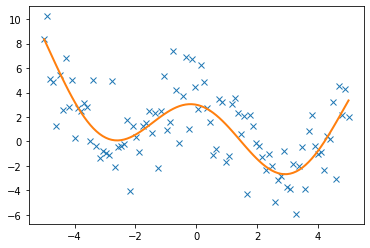

In [2]:
plt.plot(x, data, "x")
plt.plot(x, y, linewidth=2)
plt.show()

In [3]:
import pymc3 as pm

with pm.Model() as model:
    beta = pm.Normal('beta', mu=0, sigma=3, shape=3)
    comb = beta[0] * x + beta[1] * x ** 2 + beta[2] * np.cos(x)
    sigma = pm.HalfNormal("sigma", sigma=10)
    yhat = pm.Normal('yhat', mu=comb, sigma=sigma, observed=data)

    trace = pm.sample(5000, chains=2)

/var/folders/4_/vrr8kzqn5b9dxsprxn13022m0000gn/T/ipykernel_10283/2009850971.py:9: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  trace = pm.sample(5000, chains=2)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 4 jobs)
NUTS: [sigma, beta]


/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 2 chains for 1_000 tune and 5_000 draw iterations (2_000 + 10_000 draws total) took 8 seconds.


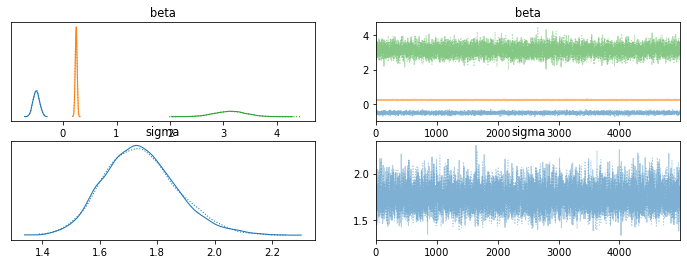

In [137]:
import arviz as az

with model:
    az.plot_trace(trace)

In [124]:
data2 = np.array(list(zip(x, data)))
np.random.shuffle(data2)

In [128]:
x2, y2 = data2[:10,0], data2[:10,1]

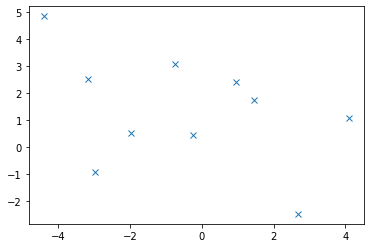

In [131]:
plt.plot(x2, y2, "x")
plt.show()

In [138]:
with pm.Model() as model2:
    beta = pm.Normal('beta', mu=0, sigma=3, shape=3)
    comb = beta[0] * x2 + beta[1] * x2 ** 2 + beta[2] * np.cos(x2)
    sigma = pm.HalfNormal("sigma", sigma=10)
    yhat = pm.Normal('yhat', mu=comb, sigma=sigma, observed=y2)

    trace2 = pm.sample(5000, chains=2)

/var/folders/4_/vrr8kzqn5b9dxsprxn13022m0000gn/T/ipykernel_67119/4004690666.py:7: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  trace2 = pm.sample(5000, chains=2)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 4 jobs)
NUTS: [sigma, beta]


/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 2 chains for 1_000 tune and 5_000 draw iterations (2_000 + 10_000 draws total) took 7 seconds.


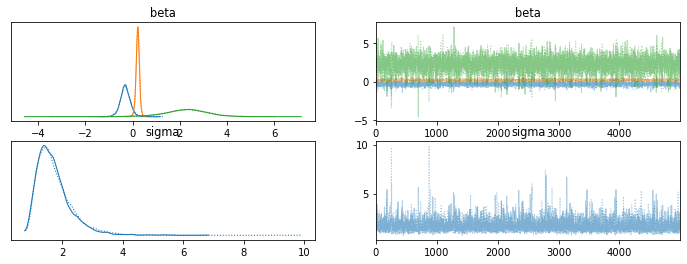

In [139]:
import arviz as az

with model2:
    az.plot_trace(trace2)

In [208]:
num_sample = 20
with model2:
    pred_func = pm.sample_posterior_predictive(trace2, var_names=["beta", "sigma"], samples=num_sample)

/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/pymc3/sampling.py:1689: UserWarning: samples parameter is smaller than nchains times ndraws, some draws and/or chains may not be represented in the returned posterior predictive sample
  warnings.warn(


In [209]:
funcs = np.array(pred_func['beta']) @ np.array([x, x**2, np.cos(x)])

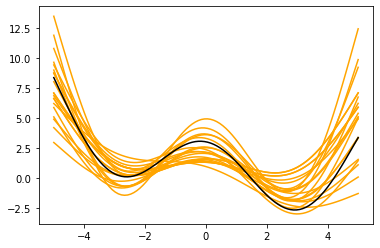

In [210]:
for i in range(num_sample):
    plt.plot(x, funcs[i,:], color='orange')
plt.plot(x, y, color='black')
plt.show()

# Multivariate Gaussian

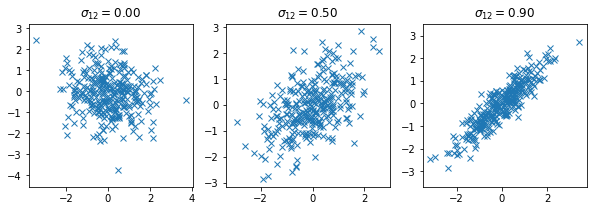

In [346]:
import numpy as np
import matplotlib.pyplot as plt

mean = [0, 0]

cov12s = [0, 0.5, 0.9]

fig, ax = plt.subplots(1, 3, figsize=(10,3))

for i, cov12 in enumerate(cov12s):
    cov = [[1, cov12],
           [cov12, 1]]

    x, y = np.random.multivariate_normal(mean, cov, 300).T
    ax[i].plot(x, y, 'x')
    ax[i].set(xlim=(-3, 3), ylim=(-3, 3))
    ax[i].set_title(r"$\sigma_{12}={%.2f}$" % cov12)
    ax[i].axis('equal')
plt.show()

In [348]:
x

array([ 0.        ,  0.1010101 ,  0.2020202 ,  0.3030303 ,  0.4040404 ,
        0.50505051,  0.60606061,  0.70707071,  0.80808081,  0.90909091,
        1.01010101,  1.11111111,  1.21212121,  1.31313131,  1.41414141,
        1.51515152,  1.61616162,  1.71717172,  1.81818182,  1.91919192,
        2.02020202,  2.12121212,  2.22222222,  2.32323232,  2.42424242,
        2.52525253,  2.62626263,  2.72727273,  2.82828283,  2.92929293,
        3.03030303,  3.13131313,  3.23232323,  3.33333333,  3.43434343,
        3.53535354,  3.63636364,  3.73737374,  3.83838384,  3.93939394,
        4.04040404,  4.14141414,  4.24242424,  4.34343434,  4.44444444,
        4.54545455,  4.64646465,  4.74747475,  4.84848485,  4.94949495,
        5.05050505,  5.15151515,  5.25252525,  5.35353535,  5.45454545,
        5.55555556,  5.65656566,  5.75757576,  5.85858586,  5.95959596,
        6.06060606,  6.16161616,  6.26262626,  6.36363636,  6.46464646,
        6.56565657,  6.66666667,  6.76767677,  6.86868687,  6.96

In [350]:
f_norm

array([-1.55714352e-01, -1.51647051e+00,  8.94884378e-01,  1.38257804e+00,
       -1.28421008e-01, -3.58046978e-01, -7.31278718e-01, -4.40062116e-01,
        1.71582030e+00,  5.42615525e-01,  2.33730659e-01, -4.33653580e-01,
        1.34880538e+00, -1.54077856e+00, -3.09063839e-01, -6.60914766e-01,
       -1.70823836e+00, -1.35364215e+00,  1.56746137e+00, -4.69011173e-01,
       -1.09075297e+00, -1.11662755e+00,  2.02097354e+00, -1.12080352e+00,
        6.37356509e-01,  8.44313911e-01,  1.68869772e+00, -2.07692813e-01,
       -7.75950595e-01, -6.88117679e-01,  7.58171924e-01, -1.48204446e+00,
        3.45366100e+00,  2.29827031e-01,  5.50497393e-01, -8.04588346e-03,
        2.13835431e-01,  1.23154337e+00,  3.14826523e-01,  3.15302319e-01,
       -1.97707836e+00, -9.32858964e-01,  1.90943183e+00, -7.06970496e-01,
        5.78494092e-01,  1.78601819e+00,  6.91955006e-01,  1.51119159e-01,
       -1.39866022e+00,  2.16693604e-03, -7.14188287e-01,  1.36700553e+00,
        1.54954826e+00,  

In [351]:
f_mvn

array([[-0.31325483,  2.3969236 ],
       [-0.18234435,  2.2309132 ],
       [-0.03375723,  2.03439213],
       [ 0.12927749,  1.81677156],
       [ 0.30267237,  1.58749176],
       [ 0.48136502,  1.35535154],
       [ 0.65930894,  1.12792658],
       [ 0.82961308,  0.91114199],
       [ 0.98484372,  0.70905099],
       [ 1.11746763,  0.52384065],
       [ 1.22039377,  0.35604864],
       [ 1.28754188,  0.20494314],
       [ 1.31435876,  0.06899287],
       [ 1.29821203, -0.05365401],
       [ 1.23859606, -0.16476105],
       [ 1.13712489, -0.26572108],
       [ 0.99730632, -0.3574271 ],
       [ 0.82413429, -0.44029557],
       [ 0.62355427, -0.51441009],
       [ 0.40188019, -0.57973462],
       [ 0.16524304, -0.63634408],
       [-0.08085524, -0.68461572],
       [-0.33182731, -0.72534852],
       [-0.5840966 , -0.75978689],
       [-0.83500778, -0.78954987],
       [-1.08258338, -0.81648195],
       [-1.32518421, -0.84245006],
       [-1.56114431, -0.86912037],
       [-1.78845475,

In [353]:
f_mvn

array([-1.01199176, -0.97282937, -0.92222374, -0.86358838, -0.80022676,
       -0.73512754, -0.67079007, -0.60909598, -0.55123606, -0.4976969 ,
       -0.44831406, -0.40238627, -0.35884419, -0.3164517 , -0.27401551,
       -0.23057356, -0.18553296, -0.13873687, -0.09045068, -0.04127169,
        0.00801694,  0.05661824,  0.10388013,  0.14940955,  0.19311187,
        0.23514639,  0.27580154,  0.31531498,  0.3536709 ,  0.39041892,
        0.42455198,  0.45447612,  0.47808644,  0.49294835,  0.49656312,
        0.48668619,  0.46165187,  0.42066375,  0.36400757,  0.29316013,
        0.21077497,  0.12054716,  0.02696927, -0.06499643, -0.15029538,
       -0.22417223, -0.28253974, -0.32229363, -0.34154495, -0.33975523,
       -0.31776116, -0.2776926 , -0.22279138, -0.15714902, -0.08539155,
       -0.01233835,  0.05732883,  0.11935679,  0.17014934,  0.20691394,
        0.22772464,  0.23150915,  0.2179751 ,  0.18749964,  0.14100614,
        0.07984866,  0.00571663, -0.0794345 , -0.17343289, -0.27

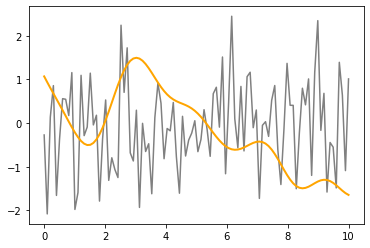

In [354]:
import numpy as np
from scipy import stats

x = np.linspace(0, 10, 100)

f_norm = stats.norm.rvs(loc=0, scale=1, size=100) # mean 0, stdev 1

plt.plot(x, f_norm, color='gray')

def exp_quad_kernel(x, knots, length=1):
    """exponentiated quadratic kernel"""
    return np.array([np.exp(-(x-k)**2 / (2*length**2)) for k in knots])

cov = exp_quad_kernel(x, x)
f_mvn = stats.multivariate_normal.rvs(cov=cov, size=1).T
plt.plot(x, f_mvn, color="orange", linewidth=2)



fig.text(0.51, -0.03, 'x', fontsize=16)
fig.text(-0.03, 0.5, 'f(x)', fontsize=16)
plt.show()

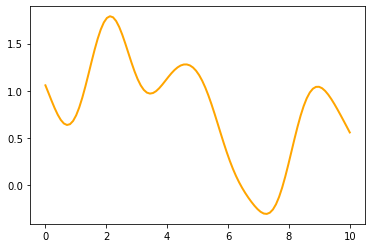

In [344]:
import numpy as np
from scipy import stats

x = np.linspace(0, 10, 100)

# f_norm = stats.norm.rvs(loc=0, scale=1, size=100) # mean 0, stdev 1
#
# plt.plot(x, f_norm, color='gray')

def exp_quad_kernel(x, knots, length=1):
    """exponentiated quadratic kernel"""
    return np.array([np.exp(-(x-k)**2 / (2*length**2)) for k in knots])

cov = exp_quad_kernel(x, x)
f_mvn = stats.multivariate_normal.rvs(cov=cov, size=1).T
plt.plot(x, f_mvn, color="orange", linewidth=2)



fig.text(0.51, -0.03, 'x', fontsize=16)
fig.text(-0.03, 0.5, 'f(x)', fontsize=16)
plt.show()

# Gaussian Process

Text(0, 0.5, 'f(x)')

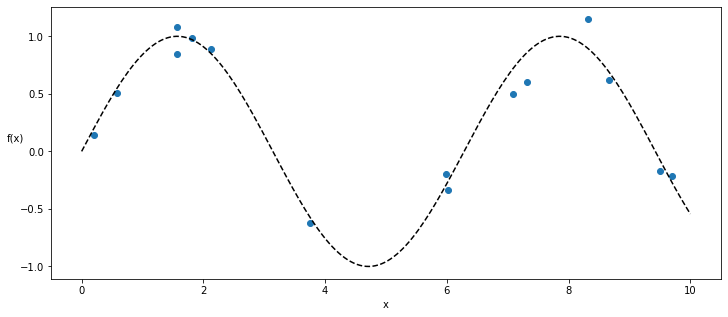

In [294]:
import pymc3 as pm
import arviz as az
import matplotlib.pyplot as plt

np.random.seed(42)
x = np.random.uniform(0, 10, size=15)
y = np.random.normal(np.sin(x), 0.1)

_, ax = plt.subplots(figsize=(12,5))
ax.plot(x, y, 'o')

true_x = np.linspace(0, 10, 200)
ax.plot(true_x, np.sin(true_x), 'k--')
ax.set_xlabel('x')
ax.set_ylabel('f(x)', rotation=0)

In [310]:
X = x[:, None]

with pm.Model() as model_gp:
    length = pm.Gamma('length', 2, 0.5)
    cov = pm.gp.cov.ExpQuad(1, ls=length)
    gp = pm.gp.Marginal(cov_func=cov)
    eps = pm.HalfNormal('eps', 25)
    y_pred = gp.marginal_likelihood('y_pref', X=X, y=y, noise=eps)
    trace_gp = pm.sample(2000, chains=1)

/var/folders/4_/vrr8kzqn5b9dxsprxn13022m0000gn/T/ipykernel_67119/350553282.py:9: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  trace_gp = pm.sample(2000, chains=1)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [eps, length]


/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 1 chain for 1_000 tune and 2_000 draw iterations (1_000 + 2_000 draws total) took 3 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


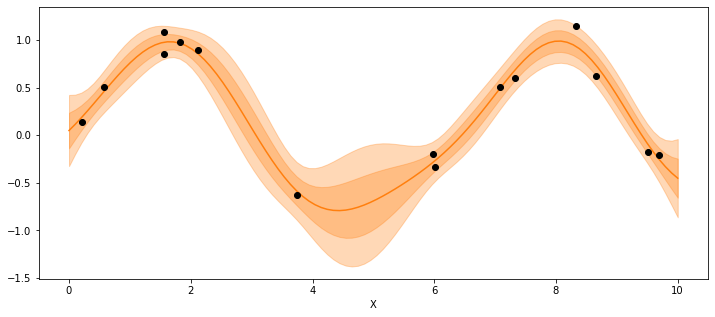

In [305]:
X_new = np.linspace(np.floor(x.min()), np.ceil(x.max()), 100)[:,None]

_, ax = plt.subplots(figsize=(12,5))

point = {'length': trace_gp['length'].mean(), 'eps': trace_gp['eps'].mean()}
mu, var = gp.predict(X_new, point=point, diag=True)
sd = var**0.5


ax.plot(X_new, mu, 'C1')
ax.fill_between(X_new.flatten(),
                 mu - sd, mu + sd,
                 color="C1",
                 alpha=0.3)

ax.fill_between(X_new.flatten(),
                 mu - 2*sd, mu + 2*sd,
                 color="C1",
                 alpha=0.3)

ax.plot(X, y, 'ko')
ax.set_xlabel('X')
plt.show()

/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/pymc3/sampling.py:1689: UserWarning: samples parameter is smaller than nchains times ndraws, some draws and/or chains may not be represented in the returned posterior predictive sample
  warnings.warn(


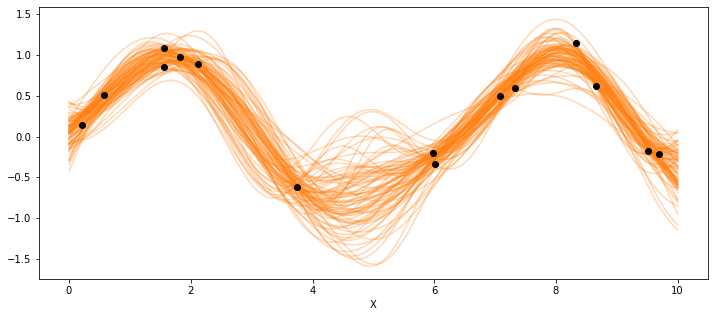

In [311]:
X_new = np.linspace(np.floor(x.min()), np.ceil(x.max()), 100)[:,None]

with model_gp:
    f_pred = gp.conditional('f_pred', X_new)
    pred_samples = pm.sample_posterior_predictive(trace_gp, var_names=["f_pred"], samples=82)

_, ax = plt.subplots(figsize=(12,5))
ax.plot(X_new, pred_samples['f_pred'].T, 'C1-', alpha=0.3)
ax.plot(X, y, 'ko')
ax.set_xlabel('X')
plt.show()

# Acquisition Function

Obtain a next sample at x=[7.97979798]


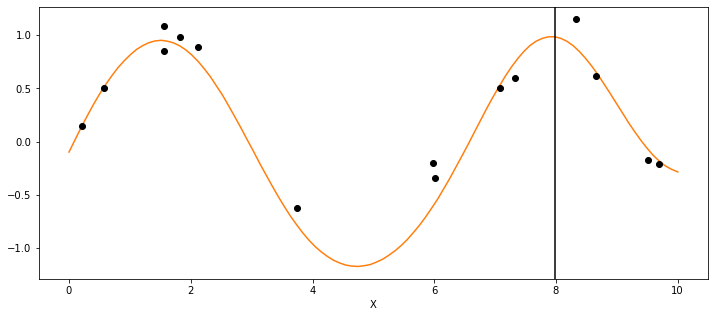

In [343]:
# ... the following code uses a function sampled from the above code's result

f = pred_samples['f_pred'][0].T
_, ax = plt.subplots(figsize=(12,5))
ax.plot(X_new, f, 'C1-')
ax.plot(X, y, 'ko')
ax.set_xlabel('X')


xstar = np.argmax(f)
print(f"Obtain a next sample at x={X_new[xstar]}")

ax.axvline(x=X_new[xstar], color="black")

plt.show()
